Shape before preprocessing: (2919, 80)
Colonnes supprimées : ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
Shape after encoding: (2919, 230)


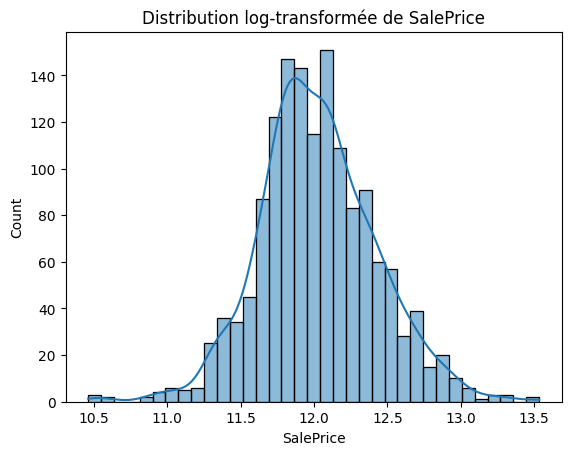

✅ Données sauvegardées dans le dossier 'data/'


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Chargement des données
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# 2️⃣ Concaténation pour traitement commun
full = pd.concat([train.drop('SalePrice', axis=1), test], axis=0)
print("Shape before preprocessing:", full.shape)

# 3️⃣ Suppression des colonnes avec > 40 % de NaN
na_ratio = full.isnull().mean()
to_drop = na_ratio[na_ratio > 0.4].index.tolist()
print("Colonnes supprimées :", to_drop)
full.drop(columns=to_drop, inplace=True)

# 4️⃣ Remplissage des valeurs manquantes
# Numériques : médiane
num_cols = full.select_dtypes(include=[np.number]).columns
full[num_cols] = full[num_cols].fillna(full[num_cols].median())

# Catégorielles : mode
cat_cols = full.select_dtypes(include=['object']).columns
full[cat_cols] = full[cat_cols].fillna(full[cat_cols].mode().iloc[0])

# 5️⃣ Encodage one-hot
full_encoded = pd.get_dummies(full, drop_first=True)
print("Shape after encoding:", full_encoded.shape)

# 6️⃣ Séparation en X_train et X_test
X_train = full_encoded.iloc[:train.shape[0], :]
X_test = full_encoded.iloc[train.shape[0]:, :]
y_train = train['SalePrice']

# 7️⃣ Transformation log1p de la target
y_train_log = np.log1p(y_train)

# 📈 Visualisation
sns.histplot(y_train_log, kde=True)
plt.title("Distribution log-transformée de SalePrice")
plt.show()

# 8️⃣ Création de X_test
X_test = full_encoded.iloc[train.shape[0]:, :]

# 9️⃣ Sauvegarde des datasets pour la suite du projet
X_train.to_csv('../data/X_train_encoded.csv', index=False)
X_test.to_csv('../data/X_test_encoded.csv', index=False)
y_train_log.to_csv('../data/y_train_log.csv', index=False)

print("✅ Données sauvegardées dans le dossier 'data/'")

